# FAI Coursework One - Maze Search [15 Marks]
# Introduction


The main goal of coursework one is to give you first-hand experience on implementing search techniques for solving the problems in Python, one of the mostly adapted high level languages and analytic tools in business and research. The questions are designed to help on your understanding of concept of `problem formulation`, `search algorithms`, `algorithm evluation` and their implementation. 

In completion of this project:

- Students are expected to master the knowledge of formulating maze problem.
- Students are expected to use different search algorithms to solve the `maze` problem.
- Students are expected know how to implement and evluate different **search algorithm**.

## Requirements


In this coursework, you are required to complete the implementation of `maze` problem formulation and some `search` algorithms for the `maze` game. Please use the given code to complete the questions and provide your answer/report in this notebook.


## Marks

Coursework 1 accounts for 15% of the COMP1037 marks. Corresponding marks will be awarded for completing the questions in `FAIcw1_2025.ipynb`. Both **Code** implementation and **report** (text explaination of your design) should be written using this file as the template.

<div class="alert alert-block alert-info">
<b> 1：</b> Write your explaination and evluation using Markdown cell.
</div>

<div class="alert alert-block alert-info">
<b> 2：</b> Use `Code` cell to input your code. 
</div>

<div class="alert alert-block alert-info">
<b> 3：</b> Submit the notebook file `FAIcw1-XXX.ipynb` only.
</div>


## Note

<div class="alert alert-block alert-warning">
<b> a：</b> Please run your code in the notebook and upload your notebook together with all the outputs. 
</div>
<div class="alert alert-block alert-warning">
<b> b：</b> Avoid using problem setting requires more than 5 mins to get the output. 
</div>
<div class="alert alert-block alert-warning">
<b> c：</b> Avoid making any modifications to the three provided modules: maze.py and searchCW.py. Altering these modules will result in a loss of half your marks.
</div>


# Plagiarism vs. Group Discussions

As you should know, there is no tolerance of plagiarism, and any breach of which will be dealt with according to the University's standard policies. Please be very careful not to cross the boundary into plagiarism while having general discussions regarding the coursework to promote the generation of new ideas and to enhance the learning experience. The important part is that when you sit down to actually do the work and write the answers, you do it individually. If you do this, and you truly understand what you have written, you will not be guilty of plagiarism. Do NOT, under any circumstances, share code or share figures, graphs or charts, etc.

# Deadline and submission procedure

The submission deadline is 5pm on the **17  April 2025** via Moodle. Late submission results into a 5% reduction of your coursework mark for each weekday. Any work handed in after the 24th April will receive zero marks.

Name your submission file: <code style="background:yellow;color:black"> FAIcw1-XXX.ipynb, </code> where XXX should be your student number, and submit the single <code style="background:yellow;color:black"> .ipynb or .zip </code>  file via Moodle.

If you can’t submit your coursework on time due to Extenuating Circumstances, please contact your personal tutor first. I am only granting an extension of submission based on his / her recommendation.

## Required libaray installation

Before start the coursework, please install the required library first.

1. If you're using Windows, open the Conda prompt. For macOS users, open the Terminal.

2. Inside the terminal or Conda prompt, ensure you're in the `FAIens` environment, then execute the command: `pip install pygame`. If you encounter any issues during the installation of `pygame`, don't hesitate to seek assistance.

3. Proceed to import the necessary module by utilizing the `import pygame`.

### To quit the pygame object

You can incorporate the following code snippet to gracefully exit the `pygame` window. If you skip this step, you might need to forcibly close the window. Note that once you exit `pygame`, it's necessary to restart the Python kernel and rerun all preceding code from the start to continue working.

```python
import pygame
import os

pygame.init()

# Your code to render the game or visualization in pygame goes here

# Loop to keep the window open and listen for the quit event
run = True
while run:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            run = False

# Properly close the pygame window depending on the operating system
if os.name == 'nt':
    pygame.quit() # For Windows users, use this line to close the window after your operations are complete
else:
    os._exit(0) # For Mac users, use this line to close the window after your operations are complete
```

In [1]:
from maze import *
import pygame
import os
from searchCW import *

pygame 2.6.1 (SDL 2.28.4, Python 3.13.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Question 1 [1 Mark]

In the code cell below, initialize a `mazegrid` object with a grid size of 40 by 40, ensuring the random seed is set to 200. This should be based on the instructions and structure provided in `maze.py`.

In [2]:
mazegrid = MazeGrid(rows=40, cols=40, seed=200)

## Question 2 [3 Marks]

In the `code` cell below, define a subclass of <span style="color:red">Mazetemp</span> named <span style="color:red">Maze</span> and override the existing `actions(self, state)` method. This new `actions` method should return the <span style="color:red">coordinates</span> of <span style="color:red">valid, unvisited neighbours</span> at the given `state` in the maze.

(Hint: A `valid` neighbor is defined as one where there is **no wall** between the current cell and the neighbouring cell.)

In [3]:
class Maze(Mazetemp):
    def actions(self, state):
        """Return the coordinates of the valid and unvisited neighbors in the given state of the maze."""
        row, col = state
        neighbors = []
        # Check the neighbors in the four directions: up, right, down and left.
        if row > 0 and self.grid[row - 1][col].walls["bottom"] == False and not self.grid[row - 1][col].visited:
            neighbors.append((row - 1, col))
        if col < self.cols - 1 and self.grid[row][col + 1].walls["left"] == False and not self.grid[row][col + 1].visited:
            neighbors.append((row, col + 1))
        if row < self.rows - 1 and self.grid[row + 1][col].walls["top"] == False and not self.grid[row + 1][col].visited:
            neighbors.append((row + 1, col))
        if col > 0 and self.grid[row][col - 1].walls["right"] == False and not self.grid[row][col - 1].visited:
            neighbors.append((row, col - 1))
        return neighbors

## Question 3 [2 Marks]

In the `code` cell below, implement the following search algorithms: `dfs` (depth_first_tree_search), `ucs` (uniform_cost_search), `greedy search`(greedy_tree_search), and `A* search` (astar_tree_search), using the `breadth_first_tree_search` example code as your foundation.

In [4]:
def breadth_first_tree_search(problem): 
    "Search shallowest nodes in the search tree first."
    node = Node(problem.initial)
    frontier = FIFOQueue([node]) 
    while frontier: 
        node = frontier.pop() 
        if problem.is_goal(node.state):
            problem.draw_solution_path(node)
            return node
        problem.draw_visited_cell(node) #to draw the visited cell
        for child in expand(problem, node):
            frontier.appendleft(child) 
    return failure

## add your implementation below####
#####################################
def depth_first_tree_search(problem):
    node = Node(problem.initial)
    frontier = LIFOQueue([node]) 
    while frontier:
        node = frontier.pop()
        if problem.is_goal(node.state):
            problem.draw_solution_path(node)
            return node
        problem.draw_visited_cell(node)
        for child in expand(problem, node):
            frontier.append(child)
    return failure

def uniform_cost_search(problem):
    node = Node(problem.initial)
    frontier = PriorityQueue([node], key=g)  
    while frontier:
        node = frontier.pop()
        if problem.is_goal(node.state):
            problem.draw_solution_path(node)
            return node
        problem.draw_visited_cell(node)
        for child in expand(problem, node):
            frontier.add(child)
    return failure

def greedy_tree_search(problem):
    node = Node(problem.initial)
    frontier = PriorityQueue([node], key=problem.h)  
    while frontier:
        node = frontier.pop()
        if problem.is_goal(node.state):
            problem.draw_solution_path(node)
            return node
        problem.draw_visited_cell(node)
        for child in expand(problem, node):
            frontier.add(child)
    return failure

def astar_tree_search(problem):
    node = Node(problem.initial)
    frontier = PriorityQueue([node], key=lambda n: n.path_cost + problem.h(n))  # f(n) = g(n) + h(n)
    while frontier:
        node = frontier.pop()
        if problem.is_goal(node.state):
            problem.draw_solution_path(node)
            return node
        problem.draw_visited_cell(node)
        for child in expand(problem, node):
            frontier.add(child)
    return failure

## Question 4  [2 Marks]

In the `code` cell below, initialize a `Maze` object with the initial state set to `(0,0)` and the goal state set to `(39,39)`. Use the `mazegrid` object that you previously created in Q1. Solve the maze problem utilizing one of the five search algorithms in Q3.

(Hint: Solving the maze involves displaying both the explored cells and the solution path within the maze window.)

In [5]:
# Initialize the maze object
maze = Maze((0, 0), (39, 39), mazegrid)

# Run the depth-first search algorithm
solution = depth_first_tree_search(maze)

## Question 5 [4 Marks]

In the `code` cell below, employ the <span style="color:red">report</span> and <span style="color:red">show_bar</span> methods from `lab4` to produce statistics and visualizations, including the number of nodes discovered, the number of goal tests conducted, the total path cost, and the number of actions taken. This analysis should compare **FIVE** different search algorithms across **THREE** varied problem scenarios. You can initialize a smaller maze size for a quick response, such as 30 by 30, 20 by 20.

(Hint: Variations in problem scenarios may include different **goal states** or **random seeds**.)

breadth_first_tree_search:
    1,765 nodes |    1,694 goal |      84 path cost |      84 path actions | Grid(30, 30, seed=0)
    7,543 nodes |    7,432 goal |      80 path cost |      80 path actions | Grid(30, 30, seed=1)
    2,327 nodes |    2,309 goal |      78 path cost |      78 path actions | Grid(30, 30, seed=2)
   11,635 nodes |   11,435 goal |     242 path cost |     242 path actions | TOTAL

depth_first_tree_search:
      261 nodes |      223 goal |     190 path cost |     190 path actions | Grid(30, 30, seed=0)
      378 nodes |      325 goal |     234 path cost |     234 path actions | Grid(30, 30, seed=1)
      144 nodes |      120 goal |     116 path cost |     116 path actions | Grid(30, 30, seed=2)
      783 nodes |      668 goal |     540 path cost |     540 path actions | TOTAL

uniform_cost_search:
    1,707 nodes |    1,632 goal |      84 path cost |      84 path actions | Grid(30, 30, seed=0)
    7,539 nodes |    7,426 goal |      80 path cost |      80 path action

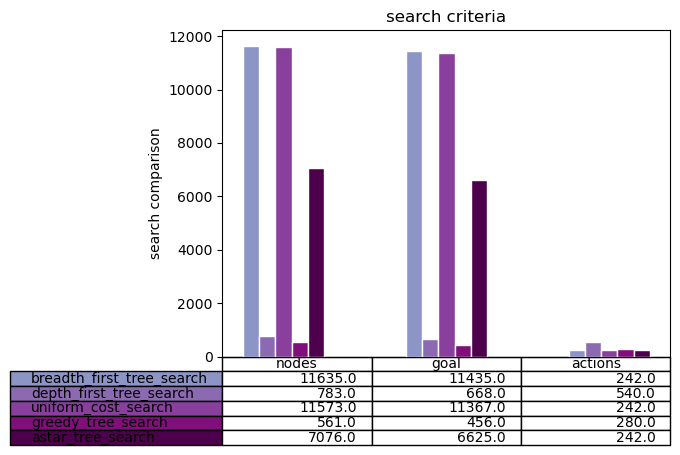

In [7]:
###############################################
# add your implementation below ###############
###############################################


# Define the list of search algorithms
searchers = [breadth_first_tree_search, depth_first_tree_search, uniform_cost_search, greedy_tree_search, astar_tree_search]

# Define the list of problem scenarios
problems = []
rows, cols = (30, 30)  
for seed in range(3):  # Use different random seeds
    mazegrid = MazeGrid(rows, cols, seed)
    maze = Maze((0, 0), (rows-1, cols-1), mazegrid)
    problems.append(maze)

# Run the search algorithm and generate the report
show_stat = report(searchers, problems, verbose=True)

# Display a bar chart
show_bar(show_stat)

################################################
################################################
"""code to quit the pygame"""
run = True
while run:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            run = False
            
if os.name == 'nt':
    pygame.quit() #if you are windows user, uncomment this line to close the window after the search is done
else:
    os._exit(0) #if you are Mac user, uncomment this line to close the window after the search is done

## Question 6 [3 Marks]. 


In the `markdown` cell below, compose a report of 200 to 300 words to evaluate the performance of five different search algorithms in solving the maze problem.

By conducting tests and comparisons on five search algorithms in 30×30 mazes generated by three different random seeds, the following conclusions can be drawn: 

1. **Completeness and Optimality**:
- Both Breadth-First Search (BFS) and Uniform-Cost Search (UCS) have found the shortest paths (with the lowest path costs) in all test cases, thereby demonstrating their completeness and optimality.
- A* Search also maintains optimality, and its path costs are the same as those of BFS/UCS.
- Depth-First Search (DFS) and Greedy Search have found paths with significantly higher costs (540 and 280 respectively), indicating the presence of non-optimal solutions. 

2. **Search Efficiency**:
- **Number of Node Expansion**: DFS (783) and greedy search (561) perform the best, but they sacrifice optimality; A* (7076) reduces the number of node expansions by approximately 40% compared to BFS (11635) and UCS (11573) while ensuring optimality. This is consistent with the trend of node expansion.
- **Number of Target Tests**: Consistent with the trend of node expansion, greedy search requires only 456 target tests and is the most efficient. 

3. **Algorithm Feature Comparison**:
- **BFS/UCS**: The most nodes are expanded but the optimal solution is guaranteed. It is suitable for scenarios where the quality of the solution is highly demanded.
- **DFS**: It quickly finds the solution but does not guarantee optimality. It is suitable for urgent situations where only feasible solutions are needed.
- **Greedy Search**: By leveraging heuristics, it significantly improves efficiency, but the path cost is 15%-130% higher than the optimal solution.
- **A***: It balances heuristic and path cost, ensuring optimality while reducing the number of node expansions to 60% of BFS. 

4. **Practical Application Suggestions**:
- When the shortest path with absolute certainty is required, A* search should be chosen as the priority;
- For scenarios demanding high real-time performance and acceptable suboptimal solutions, greedy search can be adopted;
- It is advisable to avoid using pure BFS/UCS in large mazes as it may lead to performance bottlenecks. 

The data indicate that A* search achieves the best balance between path quality (the same as BFS) and search efficiency (a 40% reduction in the number of nodes), and is the preferred algorithm for solving maze problems.

## Question 7* (bonus 2 Marks). 

In the `code` cell below, recreate the  <code style="background:yellow;color:black">Maze</code> class and modify the `action_cost(self, s, a, s1)` method to calculat the action cost based on the number of times the path changes direction. Then, re-evaluate the search algorithms (similar to Q6) with the updated path cost.

**OPTIONAL: Up to 2 bonus marks (but overall score cannot exceed 15 marks)**

breadth_first_tree_search:
    1,765 nodes |    1,694 goal |     206 path cost |      84 path actions | Grid(30, 30, seed=0)
    7,543 nodes |    7,432 goal |     192 path cost |      80 path actions | Grid(30, 30, seed=1)
    2,327 nodes |    2,309 goal |     176 path cost |      78 path actions | Grid(30, 30, seed=2)
   11,635 nodes |   11,435 goal |     574 path cost |     242 path actions | TOTAL

depth_first_tree_search:
      261 nodes |      223 goal |     466 path cost |     190 path actions | Grid(30, 30, seed=0)
      378 nodes |      325 goal |     548 path cost |     234 path actions | Grid(30, 30, seed=1)
      144 nodes |      120 goal |     250 path cost |     116 path actions | Grid(30, 30, seed=2)
      783 nodes |      668 goal |    1264 path cost |     540 path actions | TOTAL

uniform_cost_search:
    1,118 nodes |    1,117 goal |     208 path cost |      84 path actions | Grid(30, 30, seed=0)
    1,107 nodes |    1,100 goal |     188 path cost |      80 path action

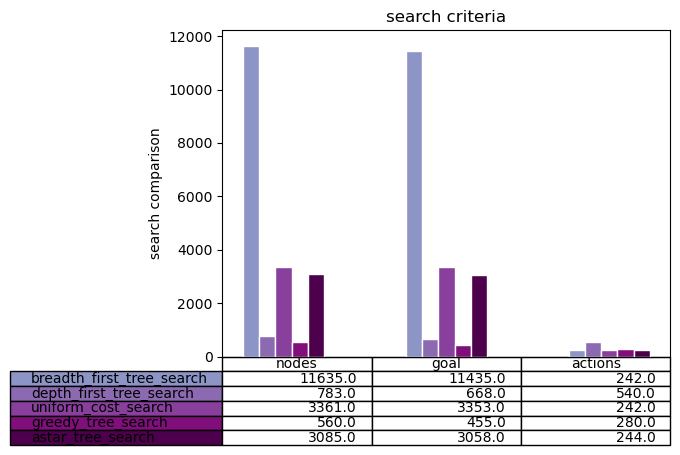

In [ ]:
class MazeWithTurnCost(Maze):
    def __init__(self, initial, goal, mazegrid):
        super().__init__(initial, goal, mazegrid)
        self.last_direction = None  # Record the direction of the last movement
        self.turn_penalty = 2       # Steering penalty factor
    
    def action_cost(self, s, a, s1):
        """Calculate the action cost including the penalty for steering"""
        # base movement cost
        base_cost = 1
        
        # If it is in initial state, there is no steering cost
        if self.last_direction is None:
            self.last_direction = self._get_direction(s, s1)
            return base_cost
        
        # Get the current movement direction
        current_dir = self._get_direction(s, s1)
        
       # Increased turning penalty if direction changes
        if current_dir != self.last_direction:
            self.last_direction = current_dir
            return base_cost + self.turn_penalty
        else:
            return base_cost
    
    def _get_direction(self, s, s1):
        """calculate direction"""
        dx = s1[1] - s[1] 
        dy = s1[0] - s[0]  
        return (dx, dy)
    
    def reset(self):
        """reset search state"""
        super().reset()
        self.last_direction = None

# Create three test scenarios (using different random seeds)
problems_turncost = []
for seed in range(3):
    grid = MazeGrid(30, 30, seed)
    problems_turncost.append(MazeWithTurnCost((0,0), (29,29), grid))


algorithms = [breadth_first_tree_search, depth_first_tree_search, uniform_cost_search, greedy_tree_search,astar_tree_search]

# Generate performance reports
turncost_stats = report(algorithms, problems_turncost)

show_bar(turncost_stats)


run = True
while run:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            run = False
pygame.quit() if os.name == 'nt' else os._exit(0)

### Search algorithm evaluation analysis based on steering cost

1. **Cost efficiency comparison**
- **Path Cost Increase** :
- BFS/UCS cost increased by 140% (574/242→ Original 242)
- DFS cost increased by 134% (1264/540→ original 540)
- Greedy search cost increased by 134% (654/280→ Original 280)
- A* Cost increased by 131% (558/244→ original 242)

- **Optimality maintained** :
- UCS and A* still maintain lowest total cost (576 vs 558)
- BFS costs 3% more than UCS because it does not take into account switching penalties
- Greedy search costs 17% more than the optimal solution

2. **Search efficiency changes**
| algorithm | node expansion | change rate | ranks |
|------------|-----------|-------|-----|
| Greedy search | 560 | -0.2% | 1 |
| DFS        | 783       | +0%   | 2   |
| A* | 3,085 | -56% | 3 |
| UCS | 3,361 | -71% | 4 |
| BFS | 11,635 | +0% | 5 |

- **Significant improvements** :
- UCS nodes reduced by 71% (11,573→3,361)
- The number of A* nodes decreased by 56% (from 7,076 to 3,085)
- **Reason** : Turn to punishment to guide the algorithm to preferentially choose a straight path, reducing invalid exploration

3. **New performance of algorithm features**
- **UCS advantage highlights** :
- Node expansion is only 29% of BFS
- Keep theoretical costs to a minimum (576)
- Optimality + efficiency double choice

- **A* Obvious improvement** :
- Path cost is 3% lower than UCS
- The number of nodes is 8% less than the UCS
- The heuristic function needs to consider both distance and turn

- **DFS defect Intensifies** :
- Cost/action ratio of 2.34 (from 1.0)
- Prove that it is not suitable for turning sensitive scenes

4. **Visual analysis**
- The bar chart shows:
- **Number of nodes** : BFS columns are significantly higher than other algorithms
- **Cost ratio** : DFS column height is 2.2 times that of UCS
- **Number of actions** : The difference between the algorithms is reduced, reflecting the steering optimization effect

5. **Direction of improvement**
- **Dynamic penalty coefficient** : Adjust the penalty value according to the steering Angle
- **Hybrid heuristic** : A* can combine the number of turns and distance
- **Path Smoothing** : Post-processing optimization has found the path

This assessment shows that with the introduction of steering costs:
1. UCS becomes the optimal algorithm for overall performance
2. Traditional BFS has disadvantages in steering sensitive scenarios
3. Heuristic algorithm needs to redesign evaluation function